In [2]:
import pandas as pd
df = pd.read_csv('/disk1/cai029/Caufussion/Benchmark_Disentangled/Metrics_result/total_metrics.csv')

import pandas as pd

# 你想要的方法顺序
method_order = ["Caunagi", "UNAGI", "scGNN", "scGGAN", 
                "GraphSCC", "scGEN", "scVI", "scGPT", "Geneformer"]

# 把 methods 列转成分类变量，并指定顺序
df["methods"] = pd.Categorical(df["methods"], categories=method_order, ordered=True)

# 如果需要根据顺序排序整个 df
df = df.sort_values(["metrics", "methods"]).reset_index(drop=True)

In [3]:
import pandas as pd

# 假设 df 已经存在
# 只保留需要的6个指标
scib_metrics = ["ARI", "NMI", "Cell-type ASW", "Isolated F1", "Isolated ASW", "Clisi_graph"]

# 给每个 methods+metrics 分别编号（即第几次实验）
df["repeat_id"] = df.groupby(["methods", "metrics"]).cumcount()

# 先 pivot 到宽表，保证每个 repeat_id 对齐
df_wide = df.pivot(index=["methods", "repeat_id"], columns="metrics", values="score")

# 只在六个指标都存在的行上计算 Overall SCIB
df_wide = df_wide.dropna(subset=scib_metrics)

df_wide["Overall SCIB"] = df_wide[scib_metrics].mean(axis=1)

# 再把 Overall SCIB 转回长表
df_scib_long = df_wide[["Overall SCIB"]].reset_index().melt(
    id_vars=["methods", "repeat_id"],
    value_name="score",
    var_name="metrics"
)

# 去掉 repeat_id 以保持原始格式一致
df_scib_long = df_scib_long.drop(columns=["repeat_id"])

# 拼接回原始 df
df_final = pd.concat([df.drop(columns=["repeat_id"]), df_scib_long], ignore_index=True)

df = df_final

/tmp/ipykernel_3739866/3350334524.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["repeat_id"] = df.groupby(["methods", "metrics"]).cumcount()


/tmp/ipykernel_3738626/3008819311.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = ax.boxplot(
/tmp/ipykernel_3738626/3008819311.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = ax.boxplot(
/tmp/ipykernel_3738626/3008819311.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = ax.boxplot(
/tmp/ipykernel_3738626/3008819311.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = ax.boxplot(
/tmp/ipykernel_3738626/3008819311.py:60: MatplotlibDeprecationWarning: T

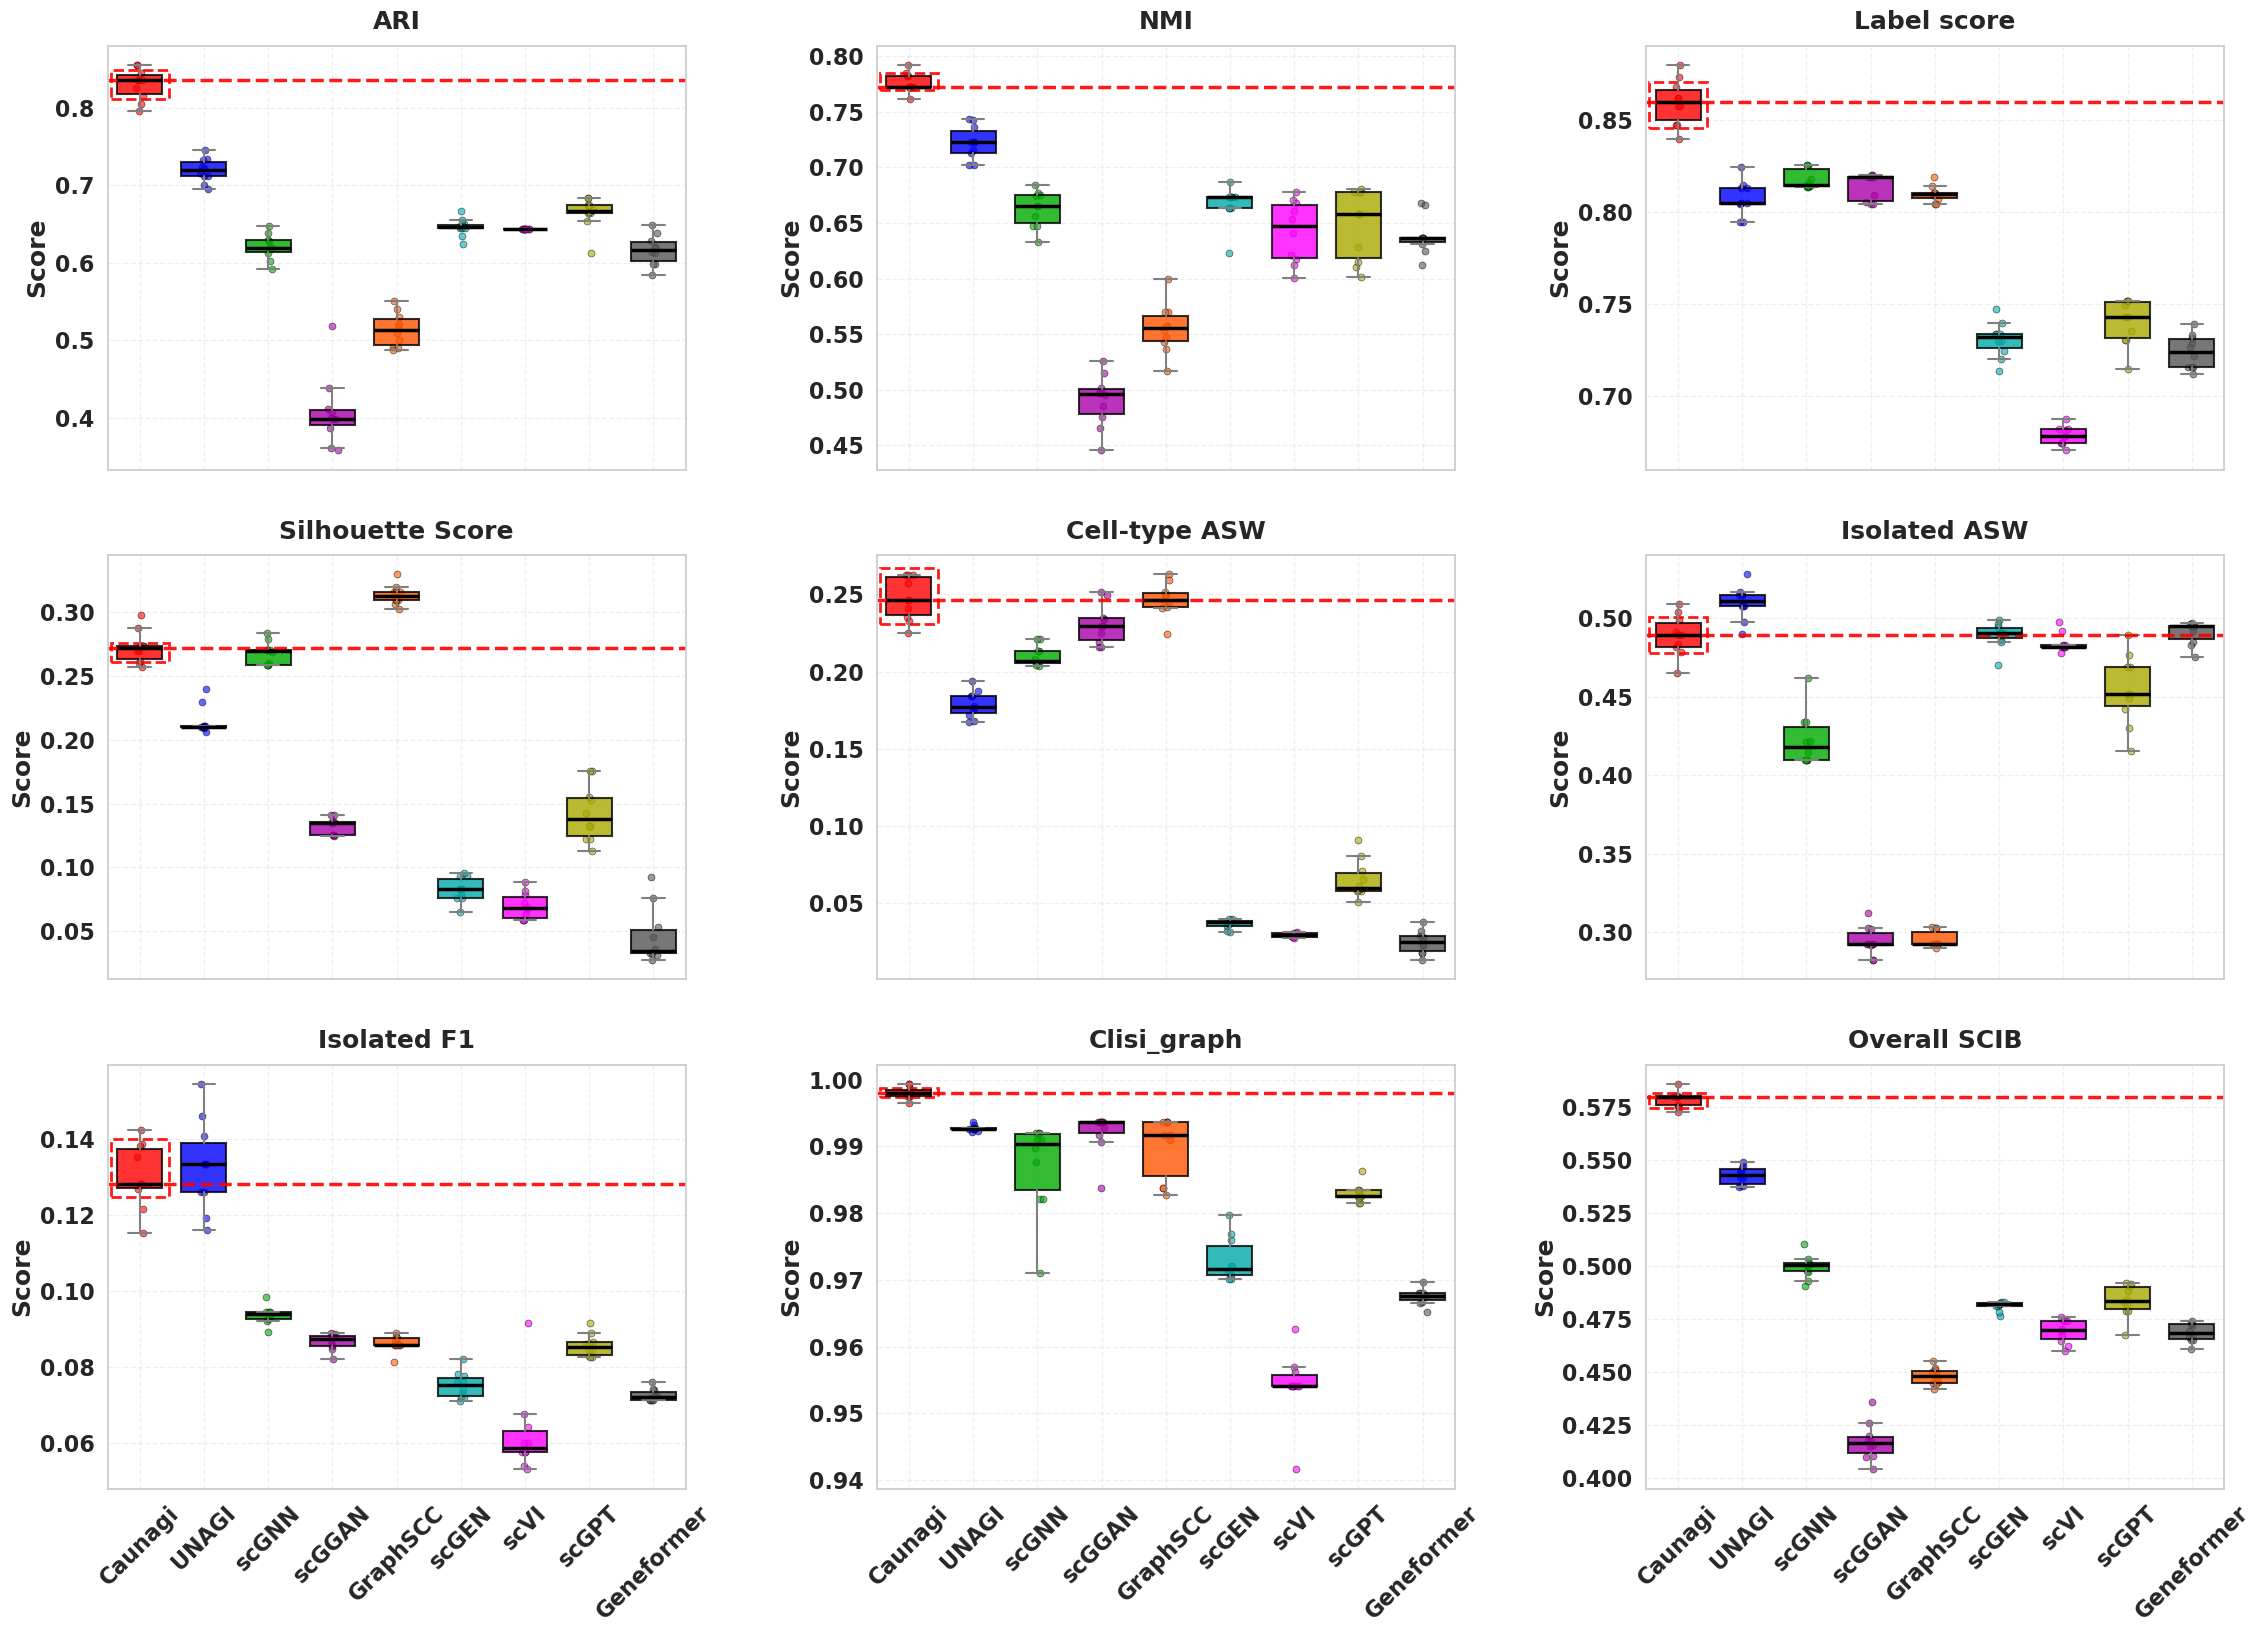

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch, Rectangle

# 设置全局样式
plt.style.use('default')
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.weight'] = 'bold'  # 设置全局字体加粗

# 假设你已经有了数据框 df，包含 methods, metrics, score 三列

# 方法顺序
method_order = ["Caunagi", "UNAGI", "scGNN", "scGGAN", 
                "GraphSCC", "scGEN", "scVI", "scGPT", "Geneformer"]
df["methods"] = pd.Categorical(df["methods"], categories=method_order, ordered=True)

# 指标顺序
metric_order = [
    "ARI", "NMI", "Label score", 
    "Silhouette Score", "Cell-type ASW",
    "Isolated ASW", "Isolated F1", "Clisi_graph",'Overall SCIB'
]
df["metrics"] = pd.Categorical(df["metrics"], categories=metric_order, ordered=True)

# 使用高对比度的颜色方案 - 确保每种方法都有明显不同的颜色
palette = [
    "#FF0000",  # 鲜红色 - Caunagi
    "#0000FF",  # 蓝色 - UNAGI
    "#00AA00",  # 绿色 - scGNN
    "#AA00AA",  # 紫色 - scGGAN
    "#FF5500",  # 橙色 - GraphSCC
    "#00AAAA",  # 青色 - scGEN
    "#FF00FF",  # 洋红色 - scVI
    "#AAAA00",  # 黄色 - scGPT
    "#555555"   # 深灰色 - Geneformer
]

# 创建图形和子图 - 增加宽度为右侧图例留出空间
fig, axes = plt.subplots(3, 3, figsize=(26, 18))
axes = axes.flatten()

# 设置全局字体大小 - 增加字体大小并加粗
plt.rcParams['font.size'] = 18
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['font.weight'] = 'bold'

# 为每个指标绘制箱线图
for i, metric in enumerate(metric_order):
    if i >= len(axes):
        break
        
    ax = axes[i]
    metric_data = df[df["metrics"] == metric]
    
    # 绘制箱线图
    boxes = ax.boxplot(
        [metric_data[metric_data["methods"] == method]["score"].values for method in method_order],
        labels=method_order,
        patch_artist=True,
        widths=0.7,
        showfliers=False
    )
    
    # 为每个箱线图设置颜色和样式
    for j, box in enumerate(boxes['boxes']):
        box.set_facecolor(palette[j])
        box.set_alpha(0.8)
        box.set_linewidth(1.5)
        box.set_edgecolor('black')  # 添加黑色边框增强对比
    
    # 设置中位数线样式
    for median in boxes['medians']:
        median.set_color('black')
        median.set_linewidth(2.5)
    
    # 设置须线样式
    for whisker in boxes['whiskers']:
        whisker.set_color('gray')
        whisker.set_linewidth(1.5)
    
    for cap in boxes['caps']:
        cap.set_color('gray')
        cap.set_linewidth(1.5)
    
    # 设置标题和标签 - 增加字体大小并加粗
    ax.set_title(metric, fontsize=18, fontweight='bold', pad=12)
    ax.set_ylabel('Score', fontsize=18, fontweight='bold')
    
    # 旋转x轴标签并调整间距 - 增加字体大小
    ax.tick_params(axis='x', rotation=45, labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    
    # 添加网格线
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # 为所有方法添加数据点
    for j, method in enumerate(method_order):
        method_data = metric_data[metric_data["methods"] == method]["score"].values
        if len(method_data) > 0:
            jitter = np.random.normal(0, 0.03, len(method_data))
            ax.scatter(np.ones(len(method_data)) * (j + 1) + jitter, method_data, 
                     color=palette[j], alpha=0.6, s=25, edgecolors='black', linewidth=0.5)

    if i < 6:  # 前6个子图（第一行和第二行）
        ax.set_xticklabels([])
        ax.set_xlabel('')  # 移除x轴标签
    
# 调整布局 - 增加右侧空间为图例留出位置
plt.tight_layout(pad=3.0, h_pad=2.0, w_pad=2.0, rect=[0, 0, 0.92, 0.98])

# 添加图例到最右侧 - 增加字体大小和加粗
# legend_elements = [Patch(facecolor=palette[i], label=method_order[i], alpha=0.8, 
#                         edgecolor='black') for i in range(len(method_order))]

# 将图例放在右侧外部 - 增加字体大小和加粗
# fig.legend(handles=legend_elements, loc='center right', ncol=1, 
#            bbox_to_anchor=(0.99, 0.5), fontsize=18, frameon=True, 
#            fancybox=True, shadow=True, borderpad=1.5, title="Methods",
#            title_fontsize=18, prop={'weight': 'bold'})

# 添加总标题 - 增加字体大小和加粗
# plt.suptitle("Methods Performance of Cell Embedding", fontsize=24, fontweight='bold', y=0.98)

# 高亮Caunagi方法
for i, metric in enumerate(metric_order):
    if i >= len(axes):
        break
        
    ax = axes[i]
    metric_data = df[df["metrics"] == metric]
    caunagi_data = metric_data[metric_data["methods"] == "Caunagi"]
    
    if not caunagi_data.empty:
        # 获取Caunagi的统计数据
        stats = caunagi_data["score"].describe()
        median_val = stats['50%']
        q1 = stats['25%']
        q3 = stats['75%']
        
        # 获取Caunagi在方法列表中的索引
        caunagi_idx = method_order.index("Caunagi") + 1
        
        # 添加中位线（水平虚线）
        ax.axhline(y=median_val, color='red', linestyle='--', linewidth=2.5, alpha=0.9)
        
        # 添加虚线框
        box_width = 0.9
        box_height = (q3 - q1) * 1.5
        
        box_x = caunagi_idx - box_width/2
        box_y = q1 - (box_height - (q3 - q1)) / 2
        
        rect = Rectangle(
            (box_x, box_y), box_width, box_height,
            fill=False, linestyle='--', edgecolor='red', linewidth=2, alpha=0.9
        )
        ax.add_patch(rect)

# 添加版权或数据来源注释
# plt.figtext(0.5, 0.01, "Data source: Experimental results", 
#             ha="center", fontsize=12, style='italic', alpha=0.7, weight='bold')
plt.savefig('/disk1/cai029/CauNagi/Benchmark/Benchmark_Disentangled/methods_performance_comparison.png', dpi=400, bbox_inches='tight', facecolor='white')
plt.savefig('/disk1/cai029/CauNagi/Benchmark/Benchmark_Disentangled/methods_performance_comparison.pdf', dpi=400, bbox_inches='tight', facecolor='white')
plt.show()

/tmp/ipykernel_3738626/2816888681.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = df_no_dbi.groupby(['methods', 'metrics'])['score'].mean().reset_index()


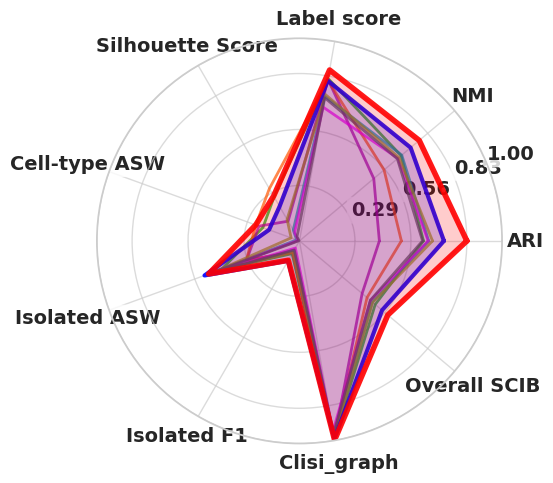

性能统计摘要:
全局值范围: 0.022 - 1.000

各方法在各指标上的平均表现:
Caunagi: 0.576 (范围: 0.130-0.998)
UNAGI: 0.536 (范围: 0.133-0.993)
scGNN: 0.509 (范围: 0.094-0.987)
scGGAN: 0.429 (范围: 0.087-0.992)
GraphSCC: 0.473 (范围: 0.086-0.990)
scGEN: 0.465 (范围: 0.037-0.973)
scVI: 0.448 (范围: 0.029-0.954)
scGPT: 0.474 (范围: 0.065-0.983)
Geneformer: 0.450 (范围: 0.025-0.968)


In [7]:
df_no_dbi = df.query("metrics != 'DBI'")
# df_no_dbi = df_no_dbi.query("metrics != 'Ove'")
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch, Rectangle
import matplotlib as mpl

# 设置全局样式
plt.style.use('default')
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.weight'] = 'bold'

# 计算每个方法在每个指标上的平均值
df_mean = df_no_dbi.groupby(['methods', 'metrics'])['score'].mean().reset_index()

# 获取所有唯一的方法和指标
methods = df_mean['methods'].unique()
metrics = df_mean['metrics'].unique()

# 确保方法与指定的顺序一致
method_order = ["Caunagi", "UNAGI", "scGNN", "scGGAN", 
                "GraphSCC", "scGEN", "scVI", "scGPT", "Geneformer"]
methods = sorted(methods, key=lambda x: method_order.index(x))

# 确保指标顺序合理 - 使用数据中实际存在的指标
all_metrics = df_mean['metrics'].unique()

# 定义我们想要的指标顺序（只包含实际存在的指标）
preferred_order = [
    "ARI", "NMI", "Label score", 
    "Silhouette Score", "Cell-type ASW",
    "Isolated ASW", "Isolated F1", "Clisi_graph", "Overall SCIB"
]

# 创建一个新的指标顺序，优先使用preferred_order中的顺序，然后添加其他指标
metric_order = [m for m in preferred_order if m in all_metrics]
# 添加不在preferred_order中的其他指标
other_metrics = [m for m in all_metrics if m not in metric_order]
metric_order.extend(sorted(other_metrics))

# 使用与箱线图完全一致的颜色方案
colors = {
    "Caunagi": "#FF0000",      # 鲜红色
    "UNAGI": "#0000FF",        # 蓝色
    "scGNN": "#00AA00",        # 绿色
    "scGGAN": "#AA00AA",       # 紫色
    "GraphSCC": "#FF5500",     # 橙色
    "scGEN": "#00AAAA",        # 青色
    "scVI": "#FF00FF",         # 洋红色
    "scGPT": "#AAAA00",        # 黄色
    "Geneformer": "#555555"    # 深灰色
}

# 创建雷达图 - 使用极坐标投影
fig, ax = plt.subplots(figsize=(7, 5), subplot_kw=dict(projection='polar'))

# 计算角度
angles = np.linspace(0, 2 * np.pi, len(metric_order), endpoint=False).tolist()
angles += angles[:1]  # 闭合图形

# 找到所有指标的整体最小值和最大值，使用统一的刻度
# 确保没有NaN或Inf值
all_scores = df_mean['score'].values
all_scores = all_scores[~np.isnan(all_scores)]  # 移除NaN值
all_scores = all_scores[~np.isinf(all_scores)]  # 移除Inf值

if len(all_scores) == 0:
    # 如果没有有效数据，设置默认范围
    global_min, global_max = 0, 1
else:
    global_min = all_scores.min() * 0.9  # 留一些边距
    global_max = 1.0  # 设置最大值为1.0，不要1.10

# 确保global_min和global_max是有效的数值
if np.isnan(global_min) or np.isinf(global_min):
    global_min = 0
if np.isnan(global_max) or np.isinf(global_max):
    global_max = 1

# 设置y轴刻度为指定的值
yticks = [0.02, 0.29, 0.56, 0.83, 1.00]
yticklabels = [f'{val:.2f}' for val in yticks]

# 1. 首先绘制网格（最低层）
ax.grid(True, alpha=0.7, zorder=1)

# 2. 然后绘制数据线
# 先绘制其他方法
for method in methods:
    if method == "Caunagi" or method == "UNAGI":
        continue  # 跳过Caunagi和UNAGI，最后绘制
        
    method_data = df_mean[df_mean['methods'] == method]
    values = []
    
    # 为每个指标获取实际值（不归一化）
    for metric in metric_order:
        metric_data = method_data[method_data['metrics'] == metric]
        if not metric_data.empty:
            value = metric_data['score'].values[0]
            # 确保值不是NaN或Inf
            if np.isnan(value) or np.isinf(value):
                value = global_min
            values.append(value)
        else:
            # 如果该方法没有该指标的数据，使用最小值
            values.append(global_min)
    
    values += values[:1]  # 闭合图形
    
    # 只绘制线条，不显示小圆点
    ax.plot(angles, values, color=colors[method], linewidth=2, marker=None, 
            label=method, alpha=0.7, zorder=2)


# 绘制ScGGAN方法（带透明阴影）
# unagi_data = df_mean[df_mean['methods'] == "scGGAN"]
# if not unagi_data.empty:
#     values = []
    
#     # 为每个指标获取实际值
#     for metric in metric_order:
#         metric_data = unagi_data[unagi_data['metrics'] == metric]
#         if not metric_data.empty:
#             value = metric_data['score'].values[0]
#             # 确保值不是NaN或Inf
#             if np.isnan(value) or np.isinf(value):
#                 value = global_min
#             values.append(value)
#         else:
#             # 如果UNAGI没有该指标的数据，使用最小值
#             values.append(global_min)
    
#     values += values[:1]  # 闭合图形
    
#     # 绘制UNAGI的填充区域
#     ax.fill(angles, values, color=colors["scGGAN"], alpha=0.2, zorder=2)
#     # 绘制UNAGI的线条
#     ax.plot(angles, values, color=colors["scGGAN"], linewidth=2, marker=None, 
#             label="scGGAN", alpha=0.9, zorder=2)


# 绘制UNAGI方法（带透明阴影）
unagi_data = df_mean[df_mean['methods'] == "UNAGI"]
if not unagi_data.empty:
    values = []
    
    # 为每个指标获取实际值
    for metric in metric_order:
        metric_data = unagi_data[unagi_data['metrics'] == metric]
        if not metric_data.empty:
            value = metric_data['score'].values[0]
            # 确保值不是NaN或Inf
            if np.isnan(value) or np.isinf(value):
                value = global_min
            values.append(value)
        else:
            # 如果UNAGI没有该指标的数据，使用最小值
            values.append(global_min)
    
    values += values[:1]  # 闭合图形
    
    # 绘制UNAGI的填充区域
    ax.fill(angles, values, color=colors["UNAGI"], alpha=0.2, zorder=2)
    # 绘制UNAGI的线条
    ax.plot(angles, values, color=colors["UNAGI"], linewidth=3, marker=None, 
            label="UNAGI", alpha=0.9, zorder=2)

# 最后绘制Caunagi方法（突出显示）
caunagi_data = df_mean[df_mean['methods'] == "Caunagi"]
if not caunagi_data.empty:
    values = []
    
    # 为每个指标获取实际值
    for metric in metric_order:
        metric_data = caunagi_data[caunagi_data['metrics'] == metric]
        if not metric_data.empty:
            value = metric_data['score'].values[0]
            # 确保值不是NaN或Inf
            if np.isnan(value) or np.isinf(value):
                value = global_min
            values.append(value)
        else:
            # 如果Caunagi没有该指标的数据，使用最小值
            values.append(global_min)
    
    values += values[:1]  # 闭合图形
    
    # 绘制Caunagi的填充区域
    ax.fill(angles, values, color=colors["Caunagi"], alpha=0.2, zorder=2)
    # 突出显示Caunagi（更粗的线条，不显示小圆点）
    ax.plot(angles, values, color='red', linewidth=4, marker=None, 
            label="Caunagi", alpha=0.9, zorder=2)
    # ax.fill(angles, values, color='red', alpha=0.2, zorder=2)
    # # 突出显示Caunagi（更粗的线条，不显示小圆点）
    # ax.plot(angles, values, color='red', linewidth=4, marker=None, 
    #         label="Caunagi", alpha=0.9, zorder=2)

# 3. 最后设置坐标轴标签和刻度（最高层）
ax.set_xticks(angles[:-1])
ax.set_yticks(yticks)

# 确保y轴限制是有效的数值
if not (np.isnan(global_min) or np.isinf(global_min) or 
        np.isnan(global_max) or np.isinf(global_max)):
    ax.set_ylim(global_min, global_max)
else:
    # 如果全局最小/最大值无效，设置默认范围
    ax.set_ylim(0, 1)

# 4. 设置标签文本，并确保它们在最上层
xtick_labels = ax.set_xticklabels(metric_order, fontsize=14, fontweight='bold')
ytick_labels = ax.set_yticklabels(yticklabels, fontsize=14, fontweight='bold')

# 为所有文本元素设置高zorder，确保它们显示在最上层
for label in xtick_labels:
    label.set_zorder(100)  # 非常高的zorder值
    label.set_bbox(dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

for label in ytick_labels:
    label.set_zorder(100)  # 非常高的zorder值
    label.set_bbox(dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

# 获取当前图例句柄和标签
handles, labels = ax.get_legend_handles_labels()

# 按照指定顺序重新排列图例
legend_order = ["Caunagi", "UNAGI", "scGNN", "scGGAN", "GraphSCC", "scGEN", "scVI", "scGPT", "Geneformer"]
# 创建一个映射，将标签映射到句柄
handle_map = dict(zip(labels, handles))
# 按照指定顺序获取句柄
handles_ordered = [handle_map[label] for label in legend_order if label in handle_map]

# 添加图例 - 放在右侧，使用指定顺序
# legend = ax.legend(handles_ordered, legend_order, 
#                   loc='center left', bbox_to_anchor=(1.1, 0.5), 
#                   fontsize=12, frameon=True, fancybox=True,
#                   shadow=True, title="Methods", title_fontsize=14)

# # 设置图例标题加粗
# legend.get_title().set_fontweight('bold')

# 添加标题
# plt.title('Methods Performance Comparison\n(All metrics use same value scale)', 
#           fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()

# 保存图片
plt.savefig('./methods_performance_radar_chart.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('./methods_performance_radar_chart.pdf', dpi=400, bbox_inches='tight', facecolor='white')

plt.show()

# 输出统计信息
print("性能统计摘要:")
print(f"全局值范围: {global_min:.3f} - {global_max:.3f}")
print("\n各方法在各指标上的平均表现:")
for method in methods:
    method_scores = df_mean[df_mean['methods'] == method]['score']
    # 过滤掉NaN和Inf值
    valid_scores = method_scores[~method_scores.isna() & ~np.isinf(method_scores)]
    if len(valid_scores) > 0:
        print(f"{method}: {valid_scores.mean():.3f} (范围: {valid_scores.min():.3f}-{valid_scores.max():.3f})")
    else:
        print(f"{method}: 无有效数据")

/tmp/ipykernel_3739866/2909584172.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = df_no_dbi.groupby(['methods', 'metrics'])['score'].mean().reset_index()


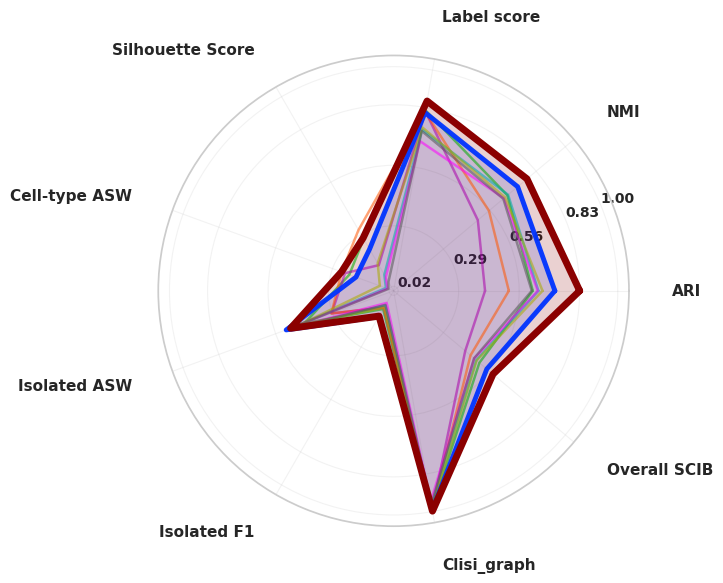

In [4]:
df_no_dbi = df.query("metrics != 'DBI'")

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib as mpl

# =========================
# 1. 基础风格
# =========================
plt.style.use('default')
sns.set_theme(style="whitegrid")

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.weight'] = 'bold'

# =========================
# 2. 数据处理
# =========================
df_mean = df_no_dbi.groupby(['methods', 'metrics'])['score'].mean().reset_index()

methods = df_mean['methods'].unique()

method_order = ["Caunagi", "UNAGI", "scGNN", "scGGAN",
                "GraphSCC", "scGEN", "scVI", "scGPT", "Geneformer"]

methods = sorted(methods, key=lambda x: method_order.index(x))

preferred_order = [
    "ARI", "NMI", "Label score",
    "Silhouette Score", "Cell-type ASW",
    "Isolated ASW", "Isolated F1", "Clisi_graph", "Overall SCIB"
]

all_metrics = df_mean['metrics'].unique()
metric_order = [m for m in preferred_order if m in all_metrics]
metric_order.extend([m for m in all_metrics if m not in metric_order])

# =========================
# 3. 颜色（强化对比）
# =========================
colors = {
    "Caunagi": "#8B0000",      # 深红（重点强化）
    "UNAGI": "#0033FF",        # 深蓝
    "scGNN": "#00AA00",
    "scGGAN": "#AA00AA",
    "GraphSCC": "#FF5500",
    "scGEN": "#00AAAA",
    "scVI": "#FF00FF",
    "scGPT": "#AAAA00",
    "Geneformer": "#555555"
}

# =========================
# 4. 极坐标图
# =========================
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(projection='polar'))

angles = np.linspace(0, 2*np.pi, len(metric_order), endpoint=False).tolist()
angles += angles[:1]

# =========================
# 5. 数值范围处理
# =========================
all_scores = df_mean['score'].values
all_scores = all_scores[~np.isnan(all_scores)]
all_scores = all_scores[~np.isinf(all_scores)]

global_min = 0
global_max = 1

yticks = [0.02, 0.29, 0.56, 0.83, 1.00]

# =========================
# 6. 网格（弱化）
# =========================
ax.grid(True, alpha=0.25, linewidth=0.8)

# =========================
# 7. 其他方法（先画）
# =========================
for method in methods:
    if method in ["Caunagi", "UNAGI"]:
        continue

    method_data = df_mean[df_mean['methods'] == method]

    values = []
    for metric in metric_order:
        v = method_data[method_data['metrics'] == metric]['score']
        if len(v) > 0:
            val = v.values[0]
            if np.isnan(val) or np.isinf(val):
                val = global_min
            values.append(val)
        else:
            values.append(global_min)

    values += values[:1]

    ax.plot(
        angles,
        values,
        color=colors.get(method, "#999999"),
        linewidth=1.8,
        alpha=0.55
    )

# =========================
# 8. UNAGI（强化）
# =========================
unagi_data = df_mean[df_mean['methods'] == "UNAGI"]
if not unagi_data.empty:
    values = []
    for metric in metric_order:
        v = unagi_data[unagi_data['metrics'] == metric]['score']
        if len(v) > 0:
            val = v.values[0]
            if np.isnan(val) or np.isinf(val):
                val = global_min
            values.append(val)
        else:
            values.append(global_min)

    values += values[:1]

    ax.fill(angles, values, color=colors["UNAGI"], alpha=0.15)
    ax.plot(
        angles,
        values,
        color=colors["UNAGI"],
        linewidth=3.5,
        alpha=0.95
    )

# =========================
# 9. Caunagi（最强突出）
# =========================
caunagi_data = df_mean[df_mean['methods'] == "Caunagi"]

if not caunagi_data.empty:
    values = []
    for metric in metric_order:
        v = caunagi_data[caunagi_data['metrics'] == metric]['score']
        if len(v) > 0:
            val = v.values[0]
            if np.isnan(val) or np.isinf(val):
                val = global_min
            values.append(val)
        else:
            values.append(global_min)

    values += values[:1]

    ax.fill(angles, values, color=colors["Caunagi"], alpha=0.18)

    ax.plot(
        angles,
        values,
        color=colors["Caunagi"],
        linewidth=5,
        alpha=1.0
    )

# =========================
# 10. 坐标轴
# =========================
ax.set_xticks(angles[:-1])

xtick_labels = ax.set_xticklabels(
    metric_order,
    fontsize=11,
    fontweight='bold'
)

# ⭐ 防重叠核心
for label, angle in zip(xtick_labels, angles[:-1]):
    angle_deg = np.degrees(angle)

    if 90 <= angle_deg <= 270:
        label.set_rotation(angle_deg + 180)
        label.set_horizontalalignment('right')
    else:
        label.set_rotation(angle_deg)
        label.set_horizontalalignment('left')

    label.set_rotation_mode('anchor')
    label.set_zorder(100)
    label.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.tick_params(axis='x', pad=18)

# y轴
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:.2f}" for y in yticks], fontsize=10)

ax.tick_params(axis='y', pad=8)

ax.set_ylim(0, 1.05)

# =========================
# 11. 保存
# =========================
plt.tight_layout()

plt.savefig('./methods_performance_radar_chart.png', dpi=300, bbox_inches='tight')
plt.savefig('./methods_performance_radar_chart.pdf', dpi=400, bbox_inches='tight')

plt.show()

/tmp/ipykernel_3739866/3910277568.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = df_no_dbi.groupby(['methods', 'metrics'])['score'].mean().reset_index()


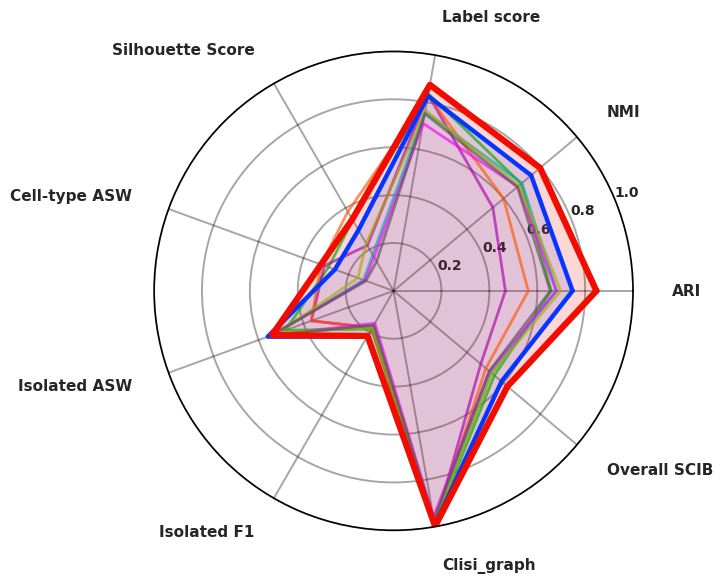

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib as mpl

# =========================
# 1. 基础风格
# =========================
plt.style.use('default')
sns.set_theme(style="whitegrid")

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.weight'] = 'bold'

# =========================
# 2. 数据处理
# =========================
df_no_dbi = df.query("metrics != 'DBI'")
df_mean = df_no_dbi.groupby(['methods', 'metrics'])['score'].mean().reset_index()

method_order = [
    "Caunagi", "UNAGI", "scGNN", "scGGAN",
    "GraphSCC", "scGEN", "scVI", "scGPT", "Geneformer"
]

preferred_order = [
    "ARI", "NMI", "Label score",
    "Silhouette Score", "Cell-type ASW",
    "Isolated ASW", "Isolated F1", "Clisi_graph", "Overall SCIB"
]

methods = [m for m in method_order if m in df_mean['methods'].unique()]

all_metrics = df_mean['metrics'].unique()
metric_order = [m for m in preferred_order if m in all_metrics]
metric_order.extend([m for m in all_metrics if m not in metric_order])

# =========================
# 3. 颜色（统一 legend + plot）
# =========================
colors = {
    "Caunagi": "#F20C00",
    "UNAGI": "#0033FF",
    "scGNN": "#00AA00",
    "scGGAN": "#AA00AA",
    "GraphSCC": "#FF5500",
    "scGEN": "#00AAAA",
    "scVI": "#FF00FF",
    "scGPT": "#AAAA00",
    "Geneformer": "#555555"
}

# =========================
# 4. 极坐标图
# =========================
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(projection='polar'))

angles = np.linspace(0, 2*np.pi, len(metric_order), endpoint=False).tolist()
angles += angles[:1]

yticks = [0.2, 0.4, 0.6, 0.8, 1.0]

# =========================
# ⭐ 关键改动1：增强网格（你说看不清的问题）
# =========================
ax.grid(True, linewidth=1.4, color='black', alpha=0.35)
ax.spines['polar'].set_color('black')
ax.spines['polar'].set_linewidth(1.2)

# =========================
# ⭐ 关键改动2：radial 拉伸（让图“贴近外圈”）
# =========================
def stretch(values):
    """把数值整体往外推，使 radar 更贴近圆圈"""
    return [min(1.0, 0.10 + 0.90 * v) for v in values]

# =========================
# 5. 画其他方法
# =========================
for method in methods:
    method_data = df_mean[df_mean['methods'] == method]

    values = []
    for metric in metric_order:
        v = method_data[method_data['metrics'] == metric]['score']
        if len(v) > 0:
            val = v.values[0]
            if np.isnan(val) or np.isinf(val):
                val = 0
        else:
            val = 0
        values.append(val)

    values = stretch(values)
    values += values[:1]

    ax.plot(
        angles,
        values,
        color=colors.get(method, "#999999"),   # ⭐ 统一 legend 颜色
        linewidth=2.0,
        alpha=0.65
    )

# =========================
# 6. UNAGI（强化）
# =========================
unagi_data = df_mean[df_mean['methods'] == "UNAGI"]
if not unagi_data.empty:
    values = []
    for metric in metric_order:
        v = unagi_data[unagi_data['metrics'] == metric]['score']
        val = v.values[0] if len(v) > 0 else 0
        values.append(val)

    values = stretch(values)
    values += values[:1]

    ax.fill(angles, values, color=colors["UNAGI"], alpha=0.12)
    ax.plot(angles, values,
            color=colors["UNAGI"],
            linewidth=3.2,
            alpha=0.95)

# =========================
# 7. Caunagi（最强突出）
# =========================
caunagi_data = df_mean[df_mean['methods'] == "Caunagi"]
if not caunagi_data.empty:
    values = []
    for metric in metric_order:
        v = caunagi_data[caunagi_data['metrics'] == metric]['score']
        val = v.values[0] if len(v) > 0 else 0
        values.append(val)

    values = stretch(values)
    values += values[:1]

    ax.fill(angles, values, color=colors["Caunagi"], alpha=0.16)
    ax.plot(angles, values,
            color=colors["Caunagi"],
            linewidth=4.5,
            alpha=1.0)

# =========================
# 8. 坐标轴优化
# =========================
ax.set_xticks(angles[:-1])

labels = ax.set_xticklabels(metric_order, fontsize=11, fontweight='bold')

for label, angle in zip(labels, angles[:-1]):
    angle_deg = np.degrees(angle)

    if 90 <= angle_deg <= 270:
        label.set_rotation(angle_deg + 180)
        label.set_horizontalalignment('right')
    else:
        label.set_rotation(angle_deg)
        label.set_horizontalalignment('left')

    label.set_rotation_mode('anchor')
    label.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='none'))

# =========================
# ⭐ 关键改动3：radial tick 更清晰
# =========================
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.0)

ax.tick_params(axis='x', pad=15)
ax.tick_params(axis='y', pad=6)

# =========================
# 9. 输出
# =========================
plt.tight_layout()
plt.savefig('./methods_performance_radar_chart.png', dpi=300, bbox_inches='tight')
plt.savefig('./methods_performance_radar_chart.pdf', dpi=400, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3739866/4071315779.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = df_no_dbi.groupby(['methods', 'metrics'])['score'].mean().reset_index()


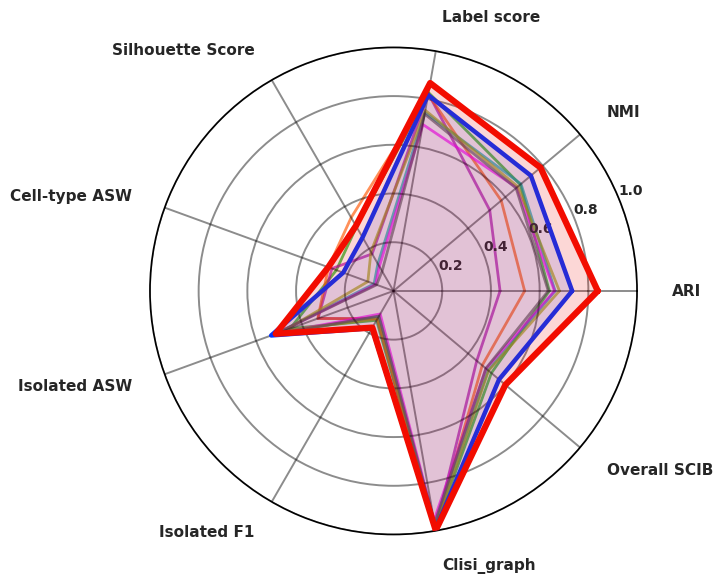

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib as mpl

# =========================
# 1. 基础风格
# =========================
plt.style.use('default')
sns.set_theme(style="whitegrid")

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.weight'] = 'bold'

# =========================
# 2. 数据处理
# =========================
df_no_dbi = df.query("metrics != 'DBI'")
df_mean = df_no_dbi.groupby(['methods', 'metrics'])['score'].mean().reset_index()

method_order = [
    "Caunagi", "UNAGI", "scGNN", "scGGAN",
    "GraphSCC", "scGEN", "scVI", "scGPT", "Geneformer"
]

preferred_order = [
    "ARI", "NMI", "Label score",
    "Silhouette Score", "Cell-type ASW",
    "Isolated ASW", "Isolated F1", "Clisi_graph", "Overall SCIB"
]

methods = [m for m in method_order if m in df_mean['methods'].unique()]

all_metrics = df_mean['metrics'].unique()
metric_order = [m for m in preferred_order if m in all_metrics]
metric_order.extend([m for m in all_metrics if m not in metric_order])

# =========================
# 3. 颜色
# =========================
colors = {
    "Caunagi": "#F20C00",
    "UNAGI": "#0033FF",
    "scGNN": "#00AA00",
    "scGGAN": "#AA00AA",
    "GraphSCC": "#FF5500",
    "scGEN": "#00AAAA",
    "scVI": "#FF00FF",
    "scGPT": "#AAAA00",
    "Geneformer": "#555555"
}

# =========================
# 4. 图
# =========================
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(projection='polar'))

angles = np.linspace(0, 2*np.pi, len(metric_order), endpoint=False).tolist()
angles += angles[:1]

yticks = [0.2, 0.4, 0.6, 0.8, 1.0]

# =========================
# ⭐ 关键优化：grid 加深 + 提升层级
# =========================
ax.set_axisbelow(False)

ax.grid(True,
        linewidth=1.4,
        color='black',
        alpha=0.45,
        zorder=0)

ax.spines['polar'].set_color('black')
ax.spines['polar'].set_linewidth(1.2)

# =========================
# ⭐ 关键修改1：缩小“向外扩张”
# =========================
def stretch(values):
    """
    轻微外推（避免贴太外或过度压缩）
    """
    return [0.05 + 0.95 * v for v in values]

# =========================
# 5. 画其他方法
# =========================
for method in methods:
    method_data = df_mean[df_mean['methods'] == method]

    values = []
    for metric in metric_order:
        v = method_data[method_data['metrics'] == metric]['score']
        val = v.values[0] if len(v) > 0 else 0
        values.append(val)

    values = stretch(values)
    values += values[:1]

    ax.plot(
        angles,
        values,
        color=colors.get(method, "#999999"),
        linewidth=2.0,
        alpha=0.65,
        zorder=2
    )

# =========================
# 6. UNAGI
# =========================
unagi_data = df_mean[df_mean['methods'] == "UNAGI"]
if not unagi_data.empty:
    values = [unagi_data[unagi_data['metrics'] == m]['score'].values[0]
              if len(unagi_data[unagi_data['metrics'] == m]) > 0 else 0
              for m in metric_order]

    values = stretch(values)
    values += values[:1]

    ax.fill(angles, values, color=colors["UNAGI"], alpha=0.12, zorder=3)
    ax.plot(angles, values,
            color=colors["UNAGI"],
            linewidth=3.2,
            zorder=4)

# =========================
# 7. Caunagi
# =========================
caunagi_data = df_mean[df_mean['methods'] == "Caunagi"]
if not caunagi_data.empty:
    values = [caunagi_data[caunagi_data['metrics'] == m]['score'].values[0]
              if len(caunagi_data[caunagi_data['metrics'] == m]) > 0 else 0
              for m in metric_order]

    values = stretch(values)
    values += values[:1]

    ax.fill(angles, values, color=colors["Caunagi"], alpha=0.16, zorder=5)
    ax.plot(angles, values,
            color=colors["Caunagi"],
            linewidth=4.5,
            zorder=6)

# =========================
# 8. 坐标轴
# =========================
ax.set_xticks(angles[:-1])

labels = ax.set_xticklabels(metric_order, fontsize=11, fontweight='bold')

for label, angle in zip(labels, angles[:-1]):
    angle_deg = np.degrees(angle)

    if 90 <= angle_deg <= 270:
        label.set_rotation(angle_deg + 180)
        label.set_horizontalalignment('right')
    else:
        label.set_rotation(angle_deg)
        label.set_horizontalalignment('left')

    label.set_rotation_mode('anchor')
    label.set_bbox(dict(facecolor='white', alpha=0.75, edgecolor='none'))

ax.tick_params(axis='x', pad=12)

# =========================
# ⭐ 关键修改2：刻度值置顶
# =========================
ax.set_yticks(yticks)
yt = ax.set_yticklabels([f"{y:.1f}" for y in yticks],
                        fontsize=10,
                        fontweight='bold')

for t in yt:
    t.set_zorder(10)
    t.set_clip_on(False)

ax.set_ylim(0, 1.0)

# =========================
# ⭐ 强制最上层
# =========================
ax.patch.set_zorder(0)

# =========================
# 9. 输出
# =========================
plt.tight_layout()
plt.savefig('./methods_performance_radar_chart.png', dpi=300, bbox_inches='tight')
plt.savefig('./methods_performance_radar_chart.pdf', dpi=400, bbox_inches='tight')
plt.show()

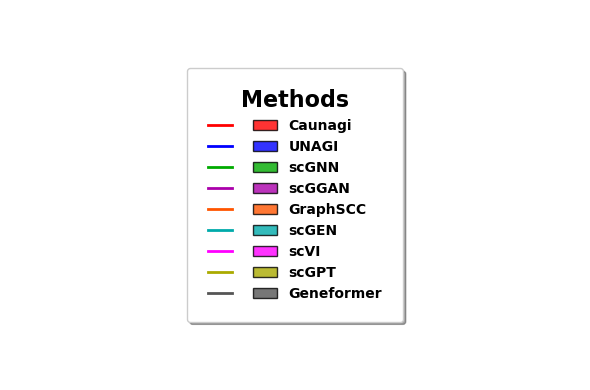

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import numpy as np

# 设置全局样式
plt.style.use('default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.weight'] = 'bold'

# 方法顺序和颜色方案（与您的两张图片保持一致）
method_order = ["Caunagi", "UNAGI", "scGNN", "scGGAN", 
                "GraphSCC", "scGEN", "scVI", "scGPT", "Geneformer"]

palette = [
    "#FF0000",  # 鲜红色 - Caunagi
    "#0000FF",  # 蓝色 - UNAGI
    "#00AA00",  # 绿色 - scGNN
    "#AA00AA",  # 紫色 - scGGAN
    "#FF5500",  # 橙色 - GraphSCC
    "#00AAAA",  # 青色 - scGEN
    "#FF00FF",  # 洋红色 - scVI
    "#AAAA00",  # 黄色 - scGPT
    "#555555"   # 深灰色 - Geneformer
]

# 创建图形
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('off')  # 隐藏坐标轴

# 创建自定义图例元素 - 每个元素包含一个长方形色块和一条线
legend_elements = []
for i, method in enumerate(method_order):
    # 创建线条
    line = Line2D([0], [0], color=palette[i], linewidth=2)
    
    # 创建长方形色块 - 增加宽度使其更明显
    color_rect = Rectangle((0, 0), 5.0, 1.0, facecolor=palette[i], edgecolor='black', alpha=0.8)
    
    # 将色块和线条组合成一个图例项
    legend_elements.append((line,color_rect, method))

# 创建自定义图例
legend = ax.legend([(elem[0], elem[1]) for elem in legend_elements],
                  [elem[2] for elem in legend_elements],
                  handler_map={tuple: HandlerTuple(ndivide=None)},
                  loc='center',
                  ncol=1,
                  fontsize=14,
                  frameon=True,
                  fancybox=True,
                  shadow=True,
                  borderpad=1.5,
                  title="Methods",
                  title_fontsize=16,
                  prop={'weight': 'bold'},
                  handlelength=5.0)  # 增加句柄长度以容纳更长的色块

# 设置图例标题加粗
legend.get_title().set_fontweight('bold')

# 调整布局
plt.tight_layout()

# 保存图例图片
plt.savefig('combined_legend_with_lines_rectangular.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('./combined_legend_with_lines_rectangular.pdf', dpi=400, bbox_inches='tight')
plt.show()